In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":   0.6,
    "lines.linewidth":  0.9,
    "legend.frameon":   False,
    "legend.fontsize":  9,
})

In [2]:
import json
import pandas as pd
from pathlib import Path

USERS_TO_KEEP = ['P004', 'P104', 'P105', 'P121']

# Ablations where results are stored under 'result' key with ft subkeys
FT_ABLATIONS = {'A1', 'A2', 'A11'}  # head_only + full_ft structure

def infer_ablation_id(filename: str) -> str:
    parts = filename.split('_')
    if parts[0] == 'grid':
        if parts[1] == 'A2':
            return '_'.join(parts[:4])   # e.g. grid_A2_k5_n10
        return '_'.join(parts[:3])       # e.g. grid_k5_n10
    elif parts[0] == 'A5':
        return '_'.join(parts[:2])       # e.g. A5_E4
    else:
        return parts[0]                  # e.g. A1, A2, M0
    
def make_row(ablation_id: str, ft_label: str, user_accs: dict) -> dict:
    all_kept_accs = list(user_accs.values())
    return {
        'Ablation_ID':     ablation_id,
        'Finetune_Method': ft_label,
        **user_accs,
        'Mean':            pd.Series(all_kept_accs).mean(),
        'Median':          pd.Series(all_kept_accs).median(),
        'Std':             pd.Series(all_kept_accs).std(),
    }
    
def parse_top_level_ft_file(data: dict, ablation_id: str) -> list[dict]:
    """For A7: ft keys live at top level with per_subject_head_acc / per_subject_full_acc."""
    rows = []
    for key, ft_label in [('per_subject_head_acc', 'head'), ('per_subject_full_acc', 'full')]:
        per_user = data[key]
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_top_level_maml_file(data: dict, ablation_id: str) -> list[dict]:
    """For A8: MAML result lives at top level under per_subject_mean."""
    rows = []
    for key, ft_label in [('per_subject_mean', 'MAML')]:
        per_user = data[key]
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_ft_file(result: dict, ablation_id: str) -> list[dict]:
    """For FT_ABLATIONS (A1, A2, A11): ft keys live under data['result'] with per_user_acc subkey."""
    rows = []
    for ft_key, ft_label in [('test_head_only', 'head'), ('test_full_ft', 'full')]:
        ft_data = result[ft_key]
        per_user = ft_data['per_user_acc']
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_top_level_ft_per_user_file(data: dict, ablation_id: str) -> list[dict]:
    """For grid_A2_kx: ft keys live at top level (not under 'result') with per_user_acc subkey."""
    rows = []
    for ft_key, ft_label in [('test_head_only', 'head'), ('test_full_ft', 'full')]:
        ft_data = data[ft_key]
        per_user = ft_data['per_user_acc']
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_maml_file(result: dict, ablation_id: str) -> list[dict]:
    per_user = result['per_user_acc']
    user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
    return [make_row(ablation_id, 'MAML', user_accs)]


In [3]:

FOLDER_V2 = Path(r"C:\Users\kdmen\OneDrive\Desktop\Spring26\MAML_MOE_NeurIPS26\raw_results\paper_fixed_trts_split_jsons_v2")

rows = []
for json_file in sorted(FOLDER_V2.glob("*.json")):
    ablation_id = infer_ablation_id(json_file.name)

    with open(json_file) as f:
        data = json.load(f)

    if ablation_id in FT_ABLATIONS:
        result = data['result']
        rows.extend(parse_ft_file(result, ablation_id))
    elif ablation_id == 'A7':
        rows.extend(parse_top_level_ft_file(data, ablation_id))
    elif ablation_id == 'A8':
        rows.extend(parse_top_level_maml_file(data, ablation_id))
    elif ablation_id.startswith('grid_A2'):
        # Top-level ft structure (test_head_only / test_full_ft) with per_user_acc subkey
        rows.extend(parse_top_level_ft_per_user_file(data, ablation_id))
    else:
        # A5 and remaining grids use 'test_results'; A4, M0, and others use 'result'
        if ablation_id.startswith('A5') or ablation_id.startswith('grid'):
            result = data['test_results']
        elif ablation_id == 'A4':
            result = data['fold_results'][0]['test_results']
        elif ablation_id == 'M0':
            result = data['result']['test_results']
        else:
            result = data['result']
        rows.extend(parse_maml_file(result, ablation_id))

df_v2 = pd.DataFrame(rows, columns=['Ablation_ID', 'Finetune_Method'] + USERS_TO_KEEP + ['Mean', 'Median', 'Std'])
print(df_v2.shape)
df_v2.head(100)

(24, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A1,head,0.679630,0.695333,0.635704,0.700519,0.677796,0.687481,0.029434
1,A1,full,0.936519,0.875037,0.881556,0.885259,0.894593,0.883407,0.028268
2,A2,head,0.744074,0.757259,0.720000,0.643333,0.716167,0.732037,0.050947
3,A2,full,0.923407,0.893037,0.895481,0.926296,0.909556,0.909444,0.017730
4,A7,head,0.928417,0.739833,0.764000,0.896917,0.832292,0.830458,0.094214
5,A7,full,0.951583,0.854917,0.854500,0.912167,0.893292,0.883542,0.047370
6,grid_A2_k1_n10,head,0.451111,0.427733,0.386200,0.350378,0.403856,0.406967,0.044627
7,grid_A2_k1_n10,full,0.781178,0.658844,0.650667,0.700822,0.697878,0.679833,0.059722
8,grid_A2_k1_n3,head,0.773333,0.775333,0.748444,0.675407,0.743130,0.760889,0.046776
9,grid_A2_k1_n3,full,0.928370,0.898741,0.912074,0.926222,0.916352,0.919148,0.013788


In [4]:
FOLDER = Path(r"C:\Users\kdmen\OneDrive\Desktop\Spring26\MAML_MOE_NeurIPS26\raw_results\paper_fixed_trts_split_jsons")

rows = []
for json_file in sorted(FOLDER.glob("*.json")):
    ablation_id = infer_ablation_id(json_file.name)

    with open(json_file) as f:
        data = json.load(f)

    if ablation_id in FT_ABLATIONS:
        result = data['result']
        rows.extend(parse_ft_file(result, ablation_id))
    elif ablation_id == 'A7':
        rows.extend(parse_top_level_ft_file(data, ablation_id))
    elif ablation_id == 'A8':
        rows.extend(parse_top_level_maml_file(data, ablation_id))
    elif ablation_id.startswith('grid_A2'):
        # Top-level ft structure (test_head_only / test_full_ft) with per_user_acc subkey
        rows.extend(parse_top_level_ft_per_user_file(data, ablation_id))
    else:
        # A5 and remaining grids use 'test_results'; A4, M0, and others use 'result'
        if ablation_id.startswith('A5') or ablation_id.startswith('grid'):
            result = data['test_results']
        elif ablation_id == 'A4':
            result = data['fold_results'][0]['test_results']
        elif ablation_id == 'M0':
            result = data['result']['test_results']
        else:
            result = data['result']
        rows.extend(parse_maml_file(result, ablation_id))

df_v1 = pd.DataFrame(rows, columns=['Ablation_ID', 'Finetune_Method'] + USERS_TO_KEEP + ['Mean', 'Median', 'Std'])
print(df_v1.shape)
df_v1.head(100)

(46, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A11,head,0.852917,0.751417,0.797667,0.760833,0.790708,0.779250,0.046024
1,A11,full,0.359333,0.348083,0.383500,0.354833,0.361438,0.357083,0.015418
2,A1,head,0.775583,0.799000,0.721833,0.807667,0.776021,0.787292,0.038583
3,A1,full,0.935333,0.885333,0.902750,0.906500,0.907479,0.904625,0.020733
4,A2,head,0.772500,0.784083,0.762417,0.701833,0.755208,0.767458,0.036668
5,A2,full,0.937417,0.903000,0.914083,0.936333,0.922708,0.925208,0.016978
6,A4,MAML,0.852750,0.827833,0.757750,0.914333,0.838167,0.840292,0.064776
7,A5_E12,MAML,0.924417,0.886417,0.875250,0.907750,0.898458,0.897083,0.021938
8,A5_E16,MAML,0.922167,0.885000,0.875250,0.908083,0.897625,0.896542,0.021383
9,A5_E20,MAML,0.926333,0.851417,0.904333,0.918333,0.900104,0.911333,0.033708


In [5]:
df = pd.concat([df_v1, df_v2]).drop_duplicates(
    subset=['Ablation_ID', 'Finetune_Method'], keep='last'
).reset_index(drop=True)

print(df.shape)
df.head(100)

(46, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A11,head,0.852917,0.751417,0.797667,0.760833,0.790708,0.779250,0.046024
1,A11,full,0.359333,0.348083,0.383500,0.354833,0.361438,0.357083,0.015418
2,A4,MAML,0.852750,0.827833,0.757750,0.914333,0.838167,0.840292,0.064776
3,A5_E12,MAML,0.924417,0.886417,0.875250,0.907750,0.898458,0.897083,0.021938
4,A5_E16,MAML,0.922167,0.885000,0.875250,0.908083,0.897625,0.896542,0.021383
5,A5_E20,MAML,0.926333,0.851417,0.904333,0.918333,0.900104,0.911333,0.033708
6,A5_E24,MAML,0.973833,0.881000,0.896000,0.945667,0.924125,0.920833,0.043150
7,A5_E32,MAML,0.885250,0.860500,0.850833,0.882000,0.869646,0.871250,0.016670
8,A5_E40,MAML,0.899750,0.888000,0.841750,0.880750,0.877563,0.884375,0.025126
9,A5_E4,MAML,0.842333,0.814250,0.827167,0.829500,0.828313,0.828333,0.011505


In [6]:
merged = df_v2.merge(df_v1, on=['Ablation_ID', 'Finetune_Method'], how='left', indicator=True)
assert (merged['_merge'] == 'both').all(), "Some df_v2 rows have no match in df_v1!"

In [7]:
mask_a5   = df['Ablation_ID'].str.startswith('A5')
mask_grid = df['Ablation_ID'].str.startswith('grid')

In [8]:
df_a5   = df[mask_a5].reset_index(drop=True)
print(df_a5.shape)
df_a5.head(20)

(8, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A5_E12,MAML,0.924417,0.886417,0.875250,0.907750,0.898458,0.897083,0.021938
1,A5_E16,MAML,0.922167,0.885000,0.875250,0.908083,0.897625,0.896542,0.021383
2,A5_E20,MAML,0.926333,0.851417,0.904333,0.918333,0.900104,0.911333,0.033708
3,A5_E24,MAML,0.973833,0.881000,0.896000,0.945667,0.924125,0.920833,0.043150
4,A5_E32,MAML,0.885250,0.860500,0.850833,0.882000,0.869646,0.871250,0.016670
5,A5_E40,MAML,0.899750,0.888000,0.841750,0.880750,0.877563,0.884375,0.025126
6,A5_E4,MAML,0.842333,0.814250,0.827167,0.829500,0.828313,0.828333,0.011505
7,A5_E8,MAML,0.937917,0.913083,0.923333,0.918917,0.923312,0.921125,0.010603


In [9]:
df_grid = df[mask_grid].reset_index(drop=True)
print(df_grid.shape)
df_grid.head(100)

(27, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,grid_k1_n10,MAML,0.756825,0.542325,0.564550,0.674000,0.634425,0.619275,0.099855
1,grid_k1_n3,MAML,0.915083,0.878583,0.903583,0.908917,0.901542,0.906250,0.016011
2,grid_k1_n5,MAML,0.854950,0.801800,0.813850,0.843800,0.828600,0.828825,0.024908
3,grid_k3_n10,MAML,0.851900,0.683700,0.604033,0.691233,0.707717,0.687467,0.103903
4,grid_k3_n3,MAML,0.969667,0.957889,0.937778,0.975222,0.960139,0.963778,0.016567
5,grid_k3_n5,MAML,0.937067,0.855933,0.843000,0.912133,0.887033,0.884033,0.044868
6,grid_k5_n10,MAML,0.844700,0.619450,0.716400,0.739850,0.730100,0.728125,0.092483
7,grid_k5_n3,MAML,0.977333,0.957667,0.927833,0.953667,0.954125,0.955667,0.020352
8,grid_k5_n5,MAML,0.952500,0.913700,0.864400,0.935400,0.916500,0.924550,0.038190
9,grid_A2_k1_n10,head,0.451111,0.427733,0.386200,0.350378,0.403856,0.406967,0.044627


In [10]:
df_rest = df[~mask_a5 & ~mask_grid].reset_index(drop=True)
print(df_rest.shape)
df_rest.head(20)

(11, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A11,head,0.852917,0.751417,0.797667,0.760833,0.790708,0.779250,0.046024
1,A11,full,0.359333,0.348083,0.383500,0.354833,0.361438,0.357083,0.015418
2,A4,MAML,0.852750,0.827833,0.757750,0.914333,0.838167,0.840292,0.064776
3,A8,MAML,0.804833,0.715083,0.533917,0.722000,0.693958,0.718542,0.114221
4,M0,MAML,0.948500,0.865917,0.923333,0.926667,0.916104,0.925000,0.035271
5,A1,head,0.679630,0.695333,0.635704,0.700519,0.677796,0.687481,0.029434
6,A1,full,0.936519,0.875037,0.881556,0.885259,0.894593,0.883407,0.028268
7,A2,head,0.744074,0.757259,0.720000,0.643333,0.716167,0.732037,0.050947
8,A2,full,0.923407,0.893037,0.895481,0.926296,0.909556,0.909444,0.017730
9,A7,head,0.928417,0.739833,0.764000,0.896917,0.832292,0.830458,0.094214


In [11]:
map_ablationID_to_name = {"M0": "MAML MOE (ours)", "A1": "No MAML", "A2": "No MAML No MoE", "A4": "No MoE", "A5": "Num Expert Sweep", 
                          "A7": "Subject-specific\nNo MAML No MoE", "A8": "Subject-specific\n MAML MOE (ours)", "A11": "Pretrained Model"}

map_finetune_to_name = {"head": "Linear Probing", "full": "Full FT", "MAML": "MAML FT"}

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

# ─── shared style ────────────────────────────────────────────────────────────
SUBJECTS = ['P004', 'P104', 'P105', 'P121']
SUBJECT_COLORS = {
    'P004': '#1f77b4',
    'P104': '#2ca02c',
    'P105': '#ff7f0e',
    'P121': '#d62728',
}
SUBJECT_MARKERS = {
    'P004': 'o',
    'P104': 's',
    'P105': '^',
    'P121': 'D',
}
BAR_FACE  = '#b5d4f4'
BAR_EDGE  = '#378add'

FONT_SIZE_TICKS       = 14
FONT_SIZE_LABELS      = 16
FONT_SIZE_LEGEND      = 13
FONT_SIZE_XTICKLABELS = 13


def _apply_common_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylabel('Accuracy (%)', fontsize=FONT_SIZE_LABELS)
    ax.tick_params(axis='both', labelsize=FONT_SIZE_TICKS)


def _subject_legend_handles(subjects):
    return [mpatches.Patch(facecolor=BAR_FACE, edgecolor=BAR_EDGE, label='Mean')] + [
        plt.Line2D([0], [0],
                   color=SUBJECT_COLORS[s],
                   marker=SUBJECT_MARKERS[s],
                   linestyle='--', linewidth=0.8, markersize=8, label=s)
        for s in subjects
    ]


def _add_legend_with_backing(ax, handles):
    """Draw legend with a white box backing."""
    ax.legend(
        handles=handles,
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        framealpha=0.85,
        loc='lower left',
    )


# ─── Figure 1: main ablations ────────────────────────────────────────────────
def figure_main_ablations(df, save_prefix='fig1_main', include_A11=True, show_lines=False):
    target_ids = ['M0', 'A1', 'A2', 'A4', 'A7', 'A8', 'A11'] if include_A11 else ['M0' 'A1', 'A2', 'A4', 'A7', 'A8']
    sub = df[df['Ablation_ID'].isin(target_ids)].copy()

    # Preserve the order of target_ids, not the dataframe order
    sub['_order'] = sub['Ablation_ID'].map({v: i for i, v in enumerate(target_ids)})
    sub = sub.sort_values('_order').drop(columns='_order')

    def make_label(row):
        ft = row['Finetune_Method']
        return f"{map_ablationID_to_name[row['Ablation_ID']]}\n{map_finetune_to_name[ft]}"

    sub['label'] = sub.apply(make_label, axis=1)

    n = len(sub)
    bar_width = 0.4
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(7, n * 1.0), 5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        if show_lines:
            ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                    linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=60, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'].tolist(), fontsize=FONT_SIZE_XTICKLABELS, 
                   rotation=45, ha='right', rotation_mode='anchor')
    ax.set_ylim(0, 100)
    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS))

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


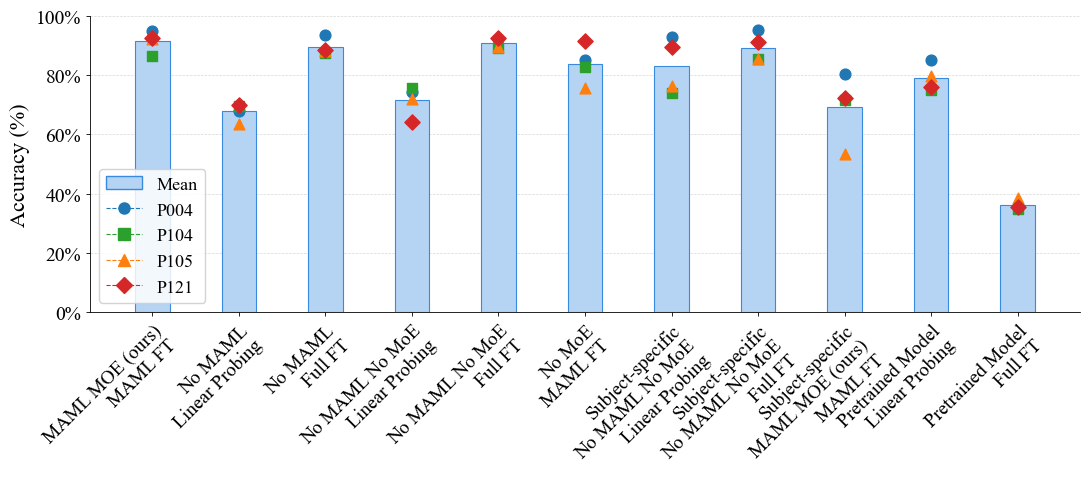

Saved fig1_main.pdf / .png


In [13]:
figure_main_ablations(df)


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── shared style ────────────────────────────────────────────────────────────
SUBJECTS = ['P004', 'P104', 'P105', 'P121']
SUBJECT_COLORS = {
    'P004': '#1f77b4',
    'P104': '#2ca02c',
    'P105': '#ff7f0e',
    'P121': '#d62728',
}
SUBJECT_MARKERS = {
    'P004': 'o',
    'P104': 's',
    'P105': '^',
    'P121': 'D',
}
BAR_FACE     = '#b5d4f4'
BAR_EDGE     = '#378add'
REF_BAR_FACE = '#d3d3d3'
REF_BAR_EDGE = '#888888'
OURS_BAR_FACE = '#f4c542'
OURS_BAR_EDGE = '#c49a00'

FONT_SIZE_TICKS        = 14
FONT_SIZE_LABELS       = 16
FONT_SIZE_LEGEND       = 12
FONT_SIZE_XTICKLABELS  = 12
FONT_SIZE_GROUP_LABEL  = 16


def _apply_common_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylabel('Accuracy (%)', fontsize=FONT_SIZE_LABELS)
    ax.tick_params(axis='both', labelsize=FONT_SIZE_TICKS)


def _subject_legend_handles(subjects):
    handles = []
    handles += [
        plt.Line2D([0], [0],
                   color=SUBJECT_COLORS[s],
                   marker=SUBJECT_MARKERS[s],
                   linestyle='--', linewidth=0.8, markersize=8, label=s)
        for s in subjects
    ]
    return handles


def _add_legend_with_backing(ax, handles, loc='lower left'):
    ax.legend(
        handles=handles,
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        framealpha=0.85,
        loc=loc,
    )


def _get_best_row(group_df, force_method=None):
    if force_method is not None:
        group_df = group_df[group_df['Finetune_Method'] == force_method]
        assert len(group_df) > 0, f"No rows with Finetune_Method='{force_method}'"
    assert len(group_df) > 0, "Empty group passed to _get_best_row"
    return group_df.loc[group_df['Mean'].idxmax()]


def _draw_group_bracket(ax, x_positions, label, bar_width, y_frac=-0.18, color="#000000"):
    x_left  = x_positions[0]  - bar_width / 2
    x_right = x_positions[-1] + bar_width / 2
    x_mid   = (x_left + x_right) / 2

    ax.annotate('',
                xy=(x_right, y_frac), xytext=(x_left, y_frac),
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.2),
                annotation_clip=False)

    ax.annotate(label,
                xy=(x_mid, y_frac - 0.04),
                xycoords=('data', 'axes fraction'),
                ha='center', va='top',
                fontsize=FONT_SIZE_GROUP_LABEL,
                color=color,
                annotation_clip=False)


def figure_main_ablations(df, save_prefix='ablations_main_result', show_lines=False):
    factorial_ids = ['A2', 'A1', 'A4', 'M0']
    reference_ids = ['A7', 'A8']
    baseline_entries = [
        ('A11', 'head',  'Linear\nProbing'),
        ('A11', 'full',  'Full\nFinetuning'),
    ]
    baseline_ids     = [e[0] for e in baseline_entries]
    baseline_methods = [e[1] for e in baseline_entries]
    baseline_labels  = [e[2] for e in baseline_entries]

    # ── Select rows ──────────────────────────────────────────────────────────
    force_method = {aid: None for aid in factorial_ids + reference_ids}
    force_method['M0'] = 'MAML'

    rows = []
    for aid in factorial_ids + reference_ids:
        group = df[df['Ablation_ID'] == aid]
        assert len(group) > 0, f"Ablation_ID '{aid}' not found in df"
        rows.append(_get_best_row(group, force_method=force_method[aid]))

    main_sub = {row['Ablation_ID']: row for row in rows}

    baseline_rows = []
    for aid, method, _ in baseline_entries:
        group = df[df['Ablation_ID'] == aid]
        assert len(group) > 0, f"Ablation_ID '{aid}' not found in df"
        baseline_rows.append(_get_best_row(group, force_method=method))

    # ── Labels ───────────────────────────────────────────────────────────────
    factorial_labels = [
        'No MAML\nNo MoE',
        'No MAML\nMoE',
        'MAML\nNo MoE',
        'MAML + MoE\n(ours)',
    ]
    reference_labels = [
        'No MAML\nNo MoE',
        'MAML + MoE',
    ]
    all_labels = factorial_labels + reference_labels + baseline_labels

    # ── x positions ──────────────────────────────────────────────────────────
    bar_width    = 0.6
    group_gap    = 0.9   # tighter gap between groups
    subj_bar_gap = 0.0   # no extra spacing between subject-specific bars

    factorial_x = np.arange(len(factorial_ids), dtype=float)

    ref_start   = factorial_x[-1] + group_gap + 1.0
    reference_x = np.array([ref_start, ref_start + 1.0 + subj_bar_gap])

    base_start  = reference_x[-1] + group_gap + 1.0
    baseline_x  = np.array([base_start + i for i in range(len(baseline_entries))], dtype=float)

    all_x = np.concatenate([factorial_x, reference_x, baseline_x])

    # ── Bar colors ───────────────────────────────────────────────────────────
    bar_faces, bar_edges = [], []
    for aid in factorial_ids:
        if aid == 'M0':
            bar_faces.append(OURS_BAR_FACE); bar_edges.append(OURS_BAR_EDGE)
        else:
            bar_faces.append(BAR_FACE);       bar_edges.append(BAR_EDGE)
    for _ in reference_ids:
        bar_faces.append(REF_BAR_FACE); bar_edges.append(REF_BAR_EDGE)
    for _ in baseline_entries:
        bar_faces.append(REF_BAR_FACE); bar_edges.append(REF_BAR_EDGE)

    # ── Combine all rows in x-order ──────────────────────────────────────────
    all_rows = [main_sub[aid] for aid in factorial_ids] \
             + [main_sub[aid] for aid in reference_ids] \
             + baseline_rows

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig_width = all_x[-1] * 1.5 + 3
    fig, ax = plt.subplots(figsize=(fig_width, 5))

    for i, (row, xi) in enumerate(zip(all_rows, all_x)):
        ax.bar(xi, row['Mean'] * 100, width=bar_width,
               color=bar_faces[i], edgecolor=bar_edges[i],
               linewidth=0.8, zorder=2)
        for subj in SUBJECTS:
            ax.scatter(xi, row[subj] * 100,
                       color=SUBJECT_COLORS[subj],
                       marker=SUBJECT_MARKERS[subj],
                       s=60, zorder=4)

    # Vertical dividers between groups
    for gap_x in [(factorial_x[-1] + reference_x[0]) / 2,
                  (reference_x[-1] + baseline_x[0]) / 2]:
        ax.axvline(gap_x, color='#aaaaaa', linestyle=':', linewidth=1.0, zorder=1)

    # Group bracket labels below x-axis
    _draw_group_bracket(ax, factorial_x, 'Cross-subject Ablations',    bar_width)
    _draw_group_bracket(ax, reference_x, 'Subject-specific Baselines', bar_width)
    _draw_group_bracket(ax, baseline_x,  'Pretrained Baseline',        bar_width)

    # Axes
    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels, fontsize=FONT_SIZE_XTICKLABELS, ha='center')
    ax.set_ylim(0, 105)
    ax.set_xlim(all_x[0] - bar_width, all_x[-1] + bar_width)

    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)

    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')

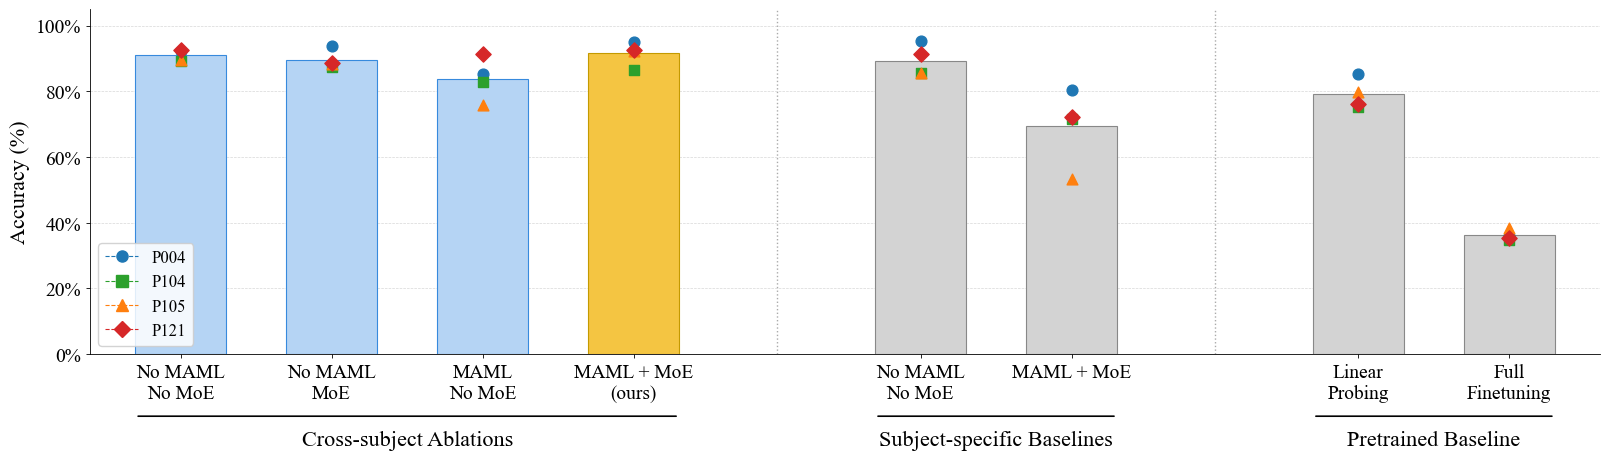

Saved ablations_main_result.pdf / .png


In [15]:
figure_main_ablations(df)

In [16]:
def figure_num_experts(df, save_prefix='fig2_experts', show_lines=False, y_min=None, legend_loc='lower left'):
    sub = df[df['Ablation_ID'].str.startswith('A5')].copy()

    def extract_experts(ablation_id):
        m = re.search(r'E(\d+)', ablation_id)
        assert m, f"Could not parse expert count from Ablation_ID: '{ablation_id}'"
        return int(m.group(1))

    sub['n_experts'] = sub['Ablation_ID'].apply(extract_experts)
    sub = sub.sort_values('n_experts')

    n = len(sub)
    bar_width = 0.4
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(5, n * 1.0), 5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        if show_lines:
            ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                    linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=60, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in sub['n_experts'].tolist()], fontsize=FONT_SIZE_XTICKLABELS)

    if y_min is None:
        ax.set_ylim(0, 100)
    else:
        if y_min == 'auto':
            all_vals = pd.concat([sub[s] * 100 for s in SUBJECTS])
            y_min = all_vals.min() * 0.75
        ax.set_ylim(y_min, 100)

    ax.set_xlabel('Number of Experts', fontsize=FONT_SIZE_LABELS, labelpad=12)
    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS), loc=legend_loc)

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')

In [19]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

def figure_num_experts(df, save_prefix='fig2_experts', show_subject_lines=True, y_min='auto', legend_loc='lower right'):
    sub = df[df['Ablation_ID'].str.startswith('A5')].copy()

    def extract_experts(ablation_id):
        m = re.search(r'E(\d+)', ablation_id)
        assert m, f"Could not parse expert count from Ablation_ID: '{ablation_id}'"
        return int(m.group(1))

    sub['n_experts'] = sub['Ablation_ID'].apply(extract_experts)
    sub = sub.sort_values('n_experts')

    x = sub['n_experts'].values
    means = sub['Mean'].values * 100
    # Compute std across subjects at each x point
    subject_vals = np.stack([sub[s].values * 100 for s in SUBJECTS], axis=0)  # (n_subjects, n_x)
    stds = subject_vals.std(axis=0)

    fig, ax = plt.subplots(figsize=(max(5, len(x) * 0.9), 5))

    # --- Shaded std band ---
    ax.fill_between(x, means - stds, means + stds,
                    color=BAR_FACE, alpha=0.25, zorder=1, label='±1 SD')

    # --- Individual subject lines (optional) ---
    if show_subject_lines:
        for subj in SUBJECTS:
            ys = sub[subj].values * 100
            ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                    linewidth=0.9, alpha=0.45, zorder=2)
            ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                       marker=SUBJECT_MARKERS[subj], s=45, zorder=3,
                       linewidths=0.5, edgecolors='white')

    # --- Mean line on top ---
    ax.plot(x, means, color=BAR_EDGE, linewidth=2.2, zorder=4, label='Mean')
    ax.scatter(x, means, color=BAR_EDGE, s=70, zorder=5,
               linewidths=0.8, edgecolors='white')

    # --- Axes ---
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x], fontsize=FONT_SIZE_XTICKLABELS)

    if y_min == 'auto':
        all_vals = subject_vals.flatten()
        pad = (all_vals.max() - all_vals.min()) * 0.15
        ax.set_ylim(max(0, all_vals.min() - pad), min(100, all_vals.max() + pad))
    elif y_min is None:
        ax.set_ylim(0, 100)
    else:
        ax.set_ylim(y_min, 100)

    ax.set_xlabel('Number of Experts', fontsize=FONT_SIZE_LABELS, labelpad=12)
    _apply_common_style(ax)

    # Subject legend handles + SD band
    subject_handles = _subject_legend_handles(SUBJECTS)
    band_handle = mpatches.Patch(color=BAR_FACE, alpha=0.4, label='±1 SD')
    mean_handle = mlines.Line2D([], [], color=BAR_EDGE, linewidth=2.2, label='Mean')
    all_handles = [mean_handle, band_handle] + subject_handles
    _add_legend_with_backing(ax, all_handles, loc=legend_loc)

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')

In [ ]:
def figure_num_experts(df, save_prefix='fig2_experts', y_min='auto', legend_loc='lower right'):
    sub = df[df['Ablation_ID'].str.startswith('A5')].copy()

    def extract_experts(ablation_id):
        m = re.search(r'E(\d+)', ablation_id)
        assert m, f"Could not parse expert count from Ablation_ID: '{ablation_id}'"
        return int(m.group(1))

    sub['n_experts'] = sub['Ablation_ID'].apply(extract_experts)
    sub = sub.sort_values('n_experts')

    x = sub['n_experts'].values
    means = sub['Mean'].values * 100
    subject_vals = np.stack([sub[s].values * 100 for s in SUBJECTS], axis=0)  # (n_subjects, n_x)
    stds = subject_vals.std(axis=0)

    fig, ax = plt.subplots(figsize=(max(5, len(x) * 0.9), 5))

    # Shaded std band
    ax.fill_between(x, means - stds, means + stds,
                    color=BAR_FACE, alpha=0.25, zorder=1, label='±1 SD')

    # Mean line
    ax.plot(x, means, color=BAR_EDGE, linewidth=2.2, zorder=4, label='Mean')
    ax.scatter(x, means, color=BAR_EDGE, s=70, zorder=5,
               linewidths=0.8, edgecolors='white')

    # Axes
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x], fontsize=FONT_SIZE_XTICKLABELS)

    if y_min == 'auto':
        all_vals = subject_vals.flatten()
        pad = (all_vals.max() - all_vals.min()) * 0.15
        ax.set_ylim(max(0, all_vals.min() - pad), min(100, all_vals.max() + pad))
    elif y_min is None:
        ax.set_ylim(0, 100)
    else:
        ax.set_ylim(y_min, 100)

    ax.set_xlabel('Number of Experts', fontsize=FONT_SIZE_LABELS, labelpad=12)
    _apply_common_style(ax)

    band_handle = mpatches.Patch(color=BAR_FACE, alpha=0.4, label='±1 SD')
    mean_handle = mlines.Line2D([], [], color=BAR_EDGE, linewidth=2.2, label='Mean')
    _add_legend_with_backing(ax, [mean_handle, band_handle], loc=legend_loc)

    plt.tight_layout()
    #plt.savefig(f'num_experts_sweep.pdf', bbox_inches='tight', dpi=500)
    #plt.savefig(f'num_experts_sweep.png', bbox_inches='tight', dpi=500)
    plt.show()
    print(f'Saved num_experts_sweep.pdf / .png')

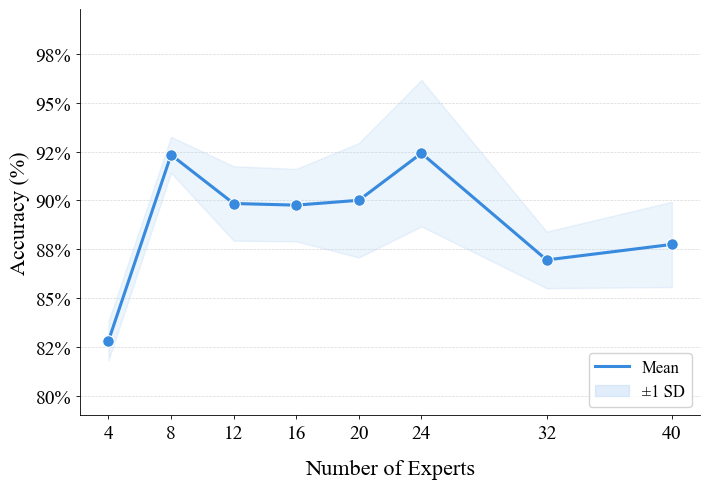

Saved num_experts_sweep.pdf / .png


In [24]:
figure_num_experts(df)


In [ ]:
figure_num_experts(df, y_min=75.0, legend_loc='lower right')

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

SUBJECTS        = USERS_TO_KEEP
SUBJECT_COLORS  = {'P004': '#e24b4a', 'P104': '#1d9e75', 'P105': '#534ab7', 'P121': '#ba7517'}
SUBJECT_MARKERS = {'P004': 'o',       'P104': 's',       'P105': '^',       'P121': 'D'}

def _apply_common_style(ax, fontsize=12):
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.grid(axis='y', linewidth=0.5, color='#cccccc', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=fontsize)

def parse_grid(ablation_id):
    mk = re.search(r'k(\d+)', ablation_id)
    mn = re.search(r'n(\d+)', ablation_id)
    assert mk and mn, f"Could not parse k/n from Ablation_ID: '{ablation_id}'"
    return int(mk.group(1)), int(mn.group(1))

def figure_grid(df,
                show_maml=True,
                show_a2_head=True,
                show_a2_full=True,
                y_baseline='chance',   # 'chance', 0, or a fixed int/float
                save_prefix='fig_grid'):
    """
    Compares mainline grid (MAML) vs grid_A2 (head / full finetune).

    Parameters
    ----------
    show_maml    : include mainline MAML bars
    show_a2_head : include A2 head-only bars
    show_a2_full : include A2 full-finetune bars
    y_baseline   : 'chance' (1/n_way per group), 0, or a fixed number
    """

    # ── Pull and parse the two sub-DataFrames ────────────────────────────────
    main = df[df['Ablation_ID'].str.match(r'^grid_k\d+_n\d+$')].copy()
    a2   = df[df['Ablation_ID'].str.match(r'^grid_A2_k\d+_n\d+$')].copy()

    assert not main.empty, "No mainline grid rows found in df"
    assert not a2.empty,   "No grid_A2 rows found in df"

    for sub in (main, a2):
        sub[['k_shot', 'n_way']] = sub['Ablation_ID'].apply(
            lambda a: pd.Series(parse_grid(a)))

    k_values = sorted(main['k_shot'].unique())
    n_values = sorted(main['n_way'].unique())

    # ── Series config: (key, label, dataframe, ft_label, color) ─────────────
    all_series = [
        ('maml', 'MAML MOE',    main, 'MAML', '#3266ad'),
        ('head', 'CNN-LSTM: Head FT', a2,   'head', '#c0560a'),
        ('full', 'CNN-LSTM: Full FT', a2,   'full', '#2a8a5e'),
    ]
    show_flags = {'maml': show_maml, 'head': show_a2_head, 'full': show_a2_full}
    series = [(k, l, d, f, c) for k, l, d, f, c in all_series if show_flags[k]]
    n_series = len(series)

    # ── Bar geometry ──────────────────────────────────────────────────────────
    # Layout: [n_way group] -> [k_shot cluster] -> [series bars]
    # Between n_way groups: padding_frac * total cluster width
    bar_width      = 0.18
    series_gap     = 0.04                           # gap between series within a k cluster
    k_cluster_w    = n_series * bar_width + (n_series - 1) * series_gap
    k_gap          = 0.25                           # gap between k clusters within an n group
    n_group_w      = len(k_values) * k_cluster_w + (len(k_values) - 1) * k_gap
    n_padding      = 0.6                            # whitespace between n-way groups
    n_step         = n_group_w + n_padding          # total x-distance between group centers

    # Center of each n-way group
    n_centers = np.arange(len(n_values)) * n_step

    # Offsets for each k cluster relative to its n-way group center
    k_cluster_starts = {}
    total_k_width = len(k_values) * k_cluster_w + (len(k_values) - 1) * k_gap
    for ki, k in enumerate(k_values):
        k_cluster_starts[k] = -total_k_width / 2 + ki * (k_cluster_w + k_gap)

    # Offsets for each series bar relative to its k cluster start
    series_offsets = {}
    for si, (s_key, *_) in enumerate(series):
        series_offsets[s_key] = si * (bar_width + series_gap)

    k_colors = {k: c for k, c in zip(k_values,
                ['#4878d0', '#ee854a', '#6acc65', '#d65f5f', '#956cb4'])}

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig_w = max(10, len(n_values) * (n_group_w + n_padding) * 1.8)
    fig   = plt.figure(figsize=(fig_w, 10))
    gs    = GridSpec(2, 2, figure=fig, height_ratios=[2.5, 1],
                     hspace=0.5, wspace=0.35)

    ax_bar   = fig.add_subplot(gs[0, :])
    #ax_hhead = fig.add_subplot(gs[1, 0])
    #ax_hfull = fig.add_subplot(gs[1, 1])

    # ── Bar chart ─────────────────────────────────────────────────────────────
    for ni, n in enumerate(n_values):
        for ki, k in enumerate(k_values):
            k_x0 = n_centers[ni] + k_cluster_starts[k]

            for s_key, s_label, s_df, ft_label, s_color in series:
                match = s_df[(s_df['k_shot'] == k) &
                             (s_df['n_way']  == n) &
                             (s_df['Finetune_Method'] == ft_label)]
                if match.empty:
                    continue
                assert len(match) == 1, \
                    f"Multiple rows for series={s_label}, k={k}, n={n}"

                xpos     = k_x0 + series_offsets[s_key] + bar_width / 2
                mean_val = match['Mean'].values[0] * 100

                bar_label = s_label if (ni == 0 and ki == 0) else '_nolegend_'
                ax_bar.bar(xpos, mean_val, width=bar_width,
                           color=s_color, alpha=0.85,
                           edgecolor='white', linewidth=0.6,
                           zorder=2, label=bar_label)

                for subj in SUBJECTS:
                    sv = match[subj].values[0] * 100
                    ax_bar.scatter(xpos, sv,
                                   color=SUBJECT_COLORS[subj],
                                   marker=SUBJECT_MARKERS[subj],
                                   s=35, zorder=4, linewidths=0.5,
                                   edgecolors='white')

    # ── x-axis ticks at n-way group centers ───────────────────────────────────
    ax_bar.set_xticks(n_centers)
    ax_bar.set_xticklabels([f'{n}-way' for n in n_values], fontsize=13)
    ax_bar.set_xlabel('$n$-way classification', fontsize=13)
    ax_bar.set_ylabel('Accuracy', fontsize=13)

    # ── y baseline ────────────────────────────────────────────────────────────
    if y_baseline == 'chance':
        # Draw a per-group chance line since n_way differs per group
        for ni, n in enumerate(n_values):
            chance = 100 / n
            half_w = n_group_w / 2 + k_gap / 2
            ax_bar.hlines(chance,
                          n_centers[ni] - half_w, n_centers[ni] + half_w,
                          colors='#888888', linestyles='--',
                          linewidth=1.0, zorder=3,
                          label='Chance' if ni == 0 else '_nolegend_')
        y_min = max(0, min(100 / n for n in n_values) - 5)
    else:
        y_min = int(y_baseline)

    ax_bar.set_ylim(y_min, 102)
    ax_bar.set_xlim(n_centers[0] - n_group_w / 2 - n_padding / 2,
                    n_centers[-1] + n_group_w / 2 + n_padding / 2)
    _apply_common_style(ax_bar, fontsize=12)

    # ── k-shot sub-labels below x-axis ────────────────────────────────────────
    for ni, n in enumerate(n_values):
        for ki, k in enumerate(k_values):
            k_x0      = n_centers[ni] + k_cluster_starts[k]
            k_x_mid   = k_x0 + k_cluster_w / 2
            ax_bar.text(k_x_mid, y_min - (102 - y_min) * 0.055,
                        f'k={k}', ha='center', va='top',
                        fontsize=10, fontweight='bold',
                        #color=k_colors[k]
                        color='black'
                        )

    # ── Legend ────────────────────────────────────────────────────────────────
    s_handles = [mpatches.Patch(facecolor=c, alpha=0.85, label=l)
                 for _, l, _, _, c in series]
    subj_handles = [
        plt.Line2D([0], [0], color=SUBJECT_COLORS[s], marker=SUBJECT_MARKERS[s],
                   linestyle='None', markersize=7, label=s)
        for s in SUBJECTS
    ]
    chance_handle = [mpatches.Patch(facecolor='none', edgecolor='#888888',
                                    linestyle='--', label='Chance')]
    all_handles = s_handles + (chance_handle if y_baseline == 'chance' else []) + subj_handles

    ax_bar.legend(handles=all_handles, fontsize=10, frameon=True,
                  facecolor='white', edgecolor='#cccccc',
                  loc='lower left', ncol=2, framealpha=0.9)

    # ── Difference heatmaps ───────────────────────────────────────────────────
    def build_delta_matrix(ft_label):
        mat = np.full((len(k_values), len(n_values)), np.nan)
        for ki, k in enumerate(k_values):
            for ni, n in enumerate(n_values):
                m_row = main[(main['k_shot'] == k) & (main['n_way'] == n) &
                             (main['Finetune_Method'] == 'MAML')]
                a_row = a2[(a2['k_shot'] == k) & (a2['n_way'] == n) &
                           (a2['Finetune_Method'] == ft_label)]
                if m_row.empty or a_row.empty:
                    continue
                mat[ki, ni] = (a_row['Mean'].values[0] - m_row['Mean'].values[0]) * 100
        return mat

    def draw_heatmap(ax, mat, title):
        vmax = max(np.nanmax(np.abs(mat)), 0.1)
        im   = ax.imshow(mat, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(n_values)))
        ax.set_yticks(range(len(k_values)))
        ax.set_xticklabels([f'{n}-way' for n in n_values], fontsize=11)
        ax.set_yticklabels([f'k={k}' for k in k_values], fontsize=11)
        ax.set_xlabel('$n$-way', fontsize=11)
        ax.set_title(title, fontsize=12, pad=8)
        for ki in range(len(k_values)):
            for ni in range(len(n_values)):
                v = mat[ki, ni]
                if not np.isnan(v):
                    ax.text(ni, ki, f'{v:+.1f}', ha='center', va='center',
                            fontsize=10,
                            color='white' if abs(v) > vmax * 0.6 else '#222222')
        plt.colorbar(im, ax=ax, shrink=0.85, label='Δ pp (A2 − MAML)')

    #draw_heatmap(ax_hhead, build_delta_matrix('head'), 'A2 head − MAML (pp)')
    #draw_heatmap(ax_hfull, build_delta_matrix('full'), 'A2 full − MAML (pp)')

    plt.suptitle('Grid sweep: MAML vs A2 (head / full)', fontsize=14, y=1.01)
    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


In [ ]:
# Example calls
figure_grid(df)                        # all three, chance baseline (recommended)
#figure_grid(df, y_baseline=0)          # start from 0%
#figure_grid(df, show_a2_head=False)    # drop A2 head once you've decided

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Data ───────────────────────────────────────────────────────────────────────
A11_eval_sweep_dict = {1: 37.60, 5: 49.93, 10: 64.29, 25: 78.47, 50: 81.08, 100: 81.44, 150: 81.58}
A2_eval_sweep_dict  = {1: 39.65, 3: 63.91, 5: 80.73, 10: 88.99, 25: 88.89, 50: 87.74, 100: 86.81, 150: 86.87}
M0_eval_sweep_dict  = {1: 57.73, 3: 76.84, 5: 86.40, 10: 90.88, 25: 92.57, 50: 92.93, 100: 93.39, 150: 93.65}

# ── Style constants ────────────────────────────────────────────────────────────
COLORS  = {"M0": "#1a6faf", "A2": "#c07b2a", "A11": "#c44e52"}
DASHES  = {"M0": (),        "A2": (5, 2),     "A11": (3, 2)}
MARKERS = {"M0": "o",       "A2": "s",        "A11": "^"}
LABELS  = {
    "M0":  "MAML+MoE (proposed)",
    "A2":  "No MAML, No MoE (baseline)",
    "A11": "Pretrained (baseline)",
}

LABEL_FONTSIZE  = 12
LEGEND_FONTSIZE = 12
TICK_FONTSIZE   = 10
PANEL_LABEL_FONTSIZE = 12   # (a), (b), (c)

LINEWIDTH   = 1.8
MARKERSIZE  = 4.5

# Panel definitions: (x_lo, x_hi, x_ticks, panel_letter, panel_title)
PANELS = [
    (1,  150, [1, 5, 10, 25, 50, 100, 150], "(a)", "Full range"),
    (1,  10,  [1, 3, 5, 10],                "(b)", "Early adaptation"),
    (25, 150, [25, 50, 100, 150],           "(c)", "Plateau region"),
]

SERIES = [
    ("M0",  M0_eval_sweep_dict),
    ("A2",  A2_eval_sweep_dict),
    ("A11", A11_eval_sweep_dict),
]

def filter_range(data, lo, hi):
    return {k: v for k, v in data.items() if lo <= k <= hi}

# ── NeurIPS-style rcParams ─────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size":  3.5,
    "ytick.major.size":  3.5,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,   # embeds fonts properly for camera-ready
    "ps.fonttype":       42,
})

# ── Figure layout ──────────────────────────────────────────────────────────────
# NeurIPS textwidth ≈ 5.5 in for a full-width figure; 3 panels side by side
fig, axes = plt.subplots(
    1, 3,
    figsize=(8, 3),
    sharey=False,   # each panel has its own y-axis
)

for ax, (x_lo, x_hi, x_ticks, panel_letter, panel_title) in zip(axes, PANELS):
    for key, data in SERIES:
        subset = filter_range(data, x_lo, x_hi)
        xs = list(subset.keys())
        ys = list(subset.values())

        ax.plot(
            xs, ys,
            color=COLORS[key],
            dashes=DASHES[key],
            marker=MARKERS[key],
            markersize=MARKERSIZE,
            linewidth=LINEWIDTH,
            label=LABELS[key],
            clip_on=False,
        )

    # x-axis: explicitly set ticks to only the measured steps
    ax.set_xticks(x_ticks)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlim(x_lo - (x_hi - x_lo) * 0.05, x_hi + (x_hi - x_lo) * 0.05)

    # y-axis: 5 ticks, consistent formatting
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5, integer=False))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

    # Labels
    ax.set_xlabel("Adaptation steps", fontsize=LABEL_FONTSIZE, labelpad=3)
    ax.set_ylabel("Test accuracy (%)", fontsize=LABEL_FONTSIZE, labelpad=3)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE, pad=2)

    # Panel letter above the plot, left-aligned (NeurIPS convention)
    ax.text(
        -0.18, 1.08, panel_letter,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE,
        fontweight="bold",
        va="top", ha="left",
    )

    # Subtle panel title
    ax.set_title(panel_title, fontsize=LABEL_FONTSIZE + 0.5, pad=4, fontweight="normal")

    # Light horizontal grid to aid reading values
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.5)
    ax.set_axisbelow(True)

# ── Single shared legend below all panels ─────────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    fontsize=LEGEND_FONTSIZE,
    frameon=False,
    bbox_to_anchor=(0.5, -0.18),
    handlelength=2.0,
    columnspacing=1.5,
    handletextpad=0.5,
)

plt.tight_layout(rect=[0, 0.0, 1, 1], w_pad=2.5)

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("eval_steps_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("eval_steps_sweep.png", dpi=500, bbox_inches="tight")
plt.show()